# Student Engagement — EDA & Preprocessing
### *Branch B · Facial Engagement Classification*

---

| Field | Details |
|-------|---------|
| **Project** | Non-Invasive Cognitive Load and Student Engagement Detection |
| **Author** | Yasini Mandara Karunanayake |
| **RGU ID** | 2313473  **IIT ID** 20221151 |
| **Dataset** | [Student Concentration Image Dataset](https://www.kaggle.com/datasets/programmer3/student-concentration-image-dataset) |


---

## Notebook Overview

This notebook implements **Stage 1 of Branch B** of the multimodal pipeline.
It downloads the Kaggle Student Concentration Image Dataset, conducts a five-part EDA, applies the full preprocessing pipeline (resize → grayscale → CLAHE → HOG), performs a block-based leakage-free train/test split, balances the training set with SMOTE, and exports scaled HOG feature arrays for model training.

| Step | Description |
|------|-------------|
| 1 | Environment setup & library imports |
| 2 | Dataset download & metadata catalogue |
| 3 | Exploratory Data Analysis (5 visualisations) |
| 4 | Image quality checks (corrupt, duplicate, blur) |
| 5 | Preprocessing pipeline (resize → grayscale → CLAHE → HOG) |
| 6 | Block-based GroupShuffleSplit (leakage-free 80/20 split) |
| 7 | HOG feature visualisation |
| 8 | SMOTE class balancing |
| 9 | StandardScaler fitting & feature export |


## 1. Environment Setup

Install packages not available by default in the Google Colab environment.

- **scikit-image** - Image I/O, HOG feature extraction, CLAHE preprocessing
- **imbalanced-learn** - SMOTE oversampling for class balancing
- **opencv-python-headless** - Grayscale conversion, Laplacian-based blur detection


In [ ]:
# Install extra packages not included in the default Colab environment
!pip install -q imbalanced-learn scikit-image opencv-python-headless
print('Dependencies installed.')

Dependencies installed.


In [ ]:
# Standard library imports
import os
import warnings
import math
import hashlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
from skimage import io, color, transform, exposure
from skimage.feature import hog
from skimage.util import img_as_float
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('All imports successful.')

All imports successful.


## 2. Download Dataset via Kaggle API

The **Kaggle Student Concentration Image Dataset** (2,120 images across six sub-classes) is downloaded directly into the Colab environment via the Kaggle API.
This dataset forms the training data for facial engagement classification of the multimodal pipeline.


In [ ]:
!pip install -q kagglehub
print('kagglehub installed')


kagglehub installed


In [ ]:
# Kaggle credentials
import os
os.environ['KAGGLE_USERNAME'] = 'username'
os.environ['KAGGLE_KEY']      = 'kaggle_key'
print('Kaggle credentials set')

Kaggle credentials set


In [ ]:
import kagglehub

# Download the dataset
KAGGLE_DATASET_PATH = kagglehub.dataset_download(
    'programmer3/student-concentration-image-dataset'
)

print('Path to dataset files:', KAGGLE_DATASET_PATH)
print()

# Show top-level folder structure
import os
for root, dirs, files_ in os.walk(KAGGLE_DATASET_PATH):
    level = root.replace(KAGGLE_DATASET_PATH, '').count(os.sep)
    if level < 3:
        print('  ' * level + os.path.basename(root) + '/')
        if level == 2 and files_:
            print('  ' * (level + 1) + f'[{len(files_)} files, e.g. {files_[0]}]')


100%|██████████| 38.4M/38.4M [00:04<00:00, 8.48MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/programmer3/student-concentration-image-dataset/versions/1

1/
  Student Dataset/
    Student-engagement-dataset/


In [ ]:
# Search from kagglehub download root for the engagement dataset folder
DATA_ROOT = Path(KAGGLE_DATASET_PATH)

DATA_DIR = None
for p in DATA_ROOT.rglob('Student-engagement-dataset'):
    if p.is_dir():
        DATA_DIR = p
        break

if DATA_DIR is None:
    DATA_DIR = DATA_ROOT
    print('Student-engagement-dataset folder not found — using root:', DATA_ROOT)

# Output directory — all .npy arrays and .pkl files will be saved here
OUTPUT_DIR = Path('/content/output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Image size constants: HOG is computed on 64×64 greyscale images
IMG_SIZE        = (64, 64)
DISPLAY_SIZE    = (128, 128)

# 80% to training, 20% to test
TEST_SPLIT      = 0.20
RANDOM_STATE    = 42

# Only read files with these image extensions; ignore anything else
IMG_EXTENSIONS  = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}

# Six-to-three class remapping
CLASS_MAP = {
    'confused':     'high',
    'focused':      'high',
    'frustrated':   'medium',
    'bored':        'medium',
    'drowsy':       'low',
    'looking away': 'low',
    'looking_away': 'low',
}

# Ordered engagement levels and their integer encodings (0=low, 1=medium, 2=high)
ENGAGEMENT_LABELS = ['low', 'medium', 'high']
LABEL_ENC = {lbl: i for i, lbl in enumerate(ENGAGEMENT_LABELS)}
LABEL_DEC = {i: lbl for lbl, i in LABEL_ENC.items()}

# Colours used in all plots: red=low, orange=medium, green=high
PALETTE = {'low': '#e74c3c', 'medium': '#f39c12', 'high': '#2ecc71'}
ORIG_PALETTE = {
    'Confused':     '#3498db',
    'Focused':      '#2ecc71',
    'Frustrated':   '#e67e22',
    'Bored':        '#e74c3c',
    'Drowsy':       '#9b59b6',
    'Looking Away': '#1abc9c',
}

print('Configuration ready')
print(f'   Dataset path : {DATA_DIR}')
print(f'   Output path  : {OUTPUT_DIR}')


Configuration ready
   Dataset path : /root/.cache/kagglehub/datasets/programmer3/student-concentration-image-dataset/versions/1/Student Dataset/Student-engagement-dataset
   Output path  : /content/output


## 2. Dataset Discovery & Metadata

Walk the dataset directory tree to build a complete image catalogue. Each record captures the file path, original six-class label, remapped three-class engagement level, and integer label encoding.
Consecutive images from the same recording are grouped into temporal blocks in preparation for the block split `GroupShuffleSplit` applied in Section 6.

In [ ]:
records = []

# Walk the folder tree and build one record per image file
for parent in sorted(DATA_DIR.iterdir()):
    if not parent.is_dir():
        continue
    for cls_folder in sorted(parent.iterdir()):
        if not cls_folder.is_dir():
            continue
        cls_key    = cls_folder.name.lower()
# Map the subfolder name to the remapped engagement level
        engagement = CLASS_MAP.get(cls_key)
        if engagement is None:
            print(f'  Skipped unrecognised folder: {cls_folder.name}')
            continue

        display_name = 'Looking Away' if 'looking' in cls_key else cls_folder.name

        for img_path in cls_folder.iterdir():
            if img_path.suffix.lower() in IMG_EXTENSIONS:
                stat = img_path.stat()
# Store file path, label, and file-size metadata for each image
                records.append({
                    'path':           str(img_path),
                    'filename':       img_path.name,
                    'extension':      img_path.suffix.lower(),
                    'file_size_kb':   round(stat.st_size / 1024, 2),
                    'original_class': display_name,
                    'parent_folder':  parent.name,
                    'engagement':     engagement,
                    'label':          LABEL_ENC[engagement],
                })

# Build the dataframe and shuffle rows to remove folder-ordering bias
df = (pd.DataFrame(records)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True))

print(f'Total images collected : {len(df):,}')
print()
print(df.groupby(['parent_folder', 'original_class', 'engagement'])
        .size().reset_index(name='count').to_string(index=False))

# Assign temporal block IDs for GroupShuffleSplit
BLOCK_SIZE = 10  # frames per block

# Sort by class and filename so consecutive frames from the same video sit adjacent
df = df.sort_values(['original_class', 'filename']).reset_index(drop=True)
df['seq_within_class'] = df.groupby('original_class').cumcount()

# Group every BLOCK_SIZE consecutive frames into one block ID
# All frames in a block will always go to the same split (train or test)
df['block_id'] = (df['original_class'] + '_block_'
                  + (df['seq_within_class'] // BLOCK_SIZE).astype(str))

n_blocks = df['block_id'].nunique()
print(f'Block IDs assigned  : {n_blocks} blocks ({BLOCK_SIZE} frames each)')
print(f'Total images        : {len(df):,}')
print()
print(df.groupby('original_class')['block_id'].nunique()
        .rename('num_blocks').to_string())


Total images collected : 2,120

parent_folder original_class engagement  count
      Engaged       Confused       high    369
      Engaged        Focused       high    347
      Engaged     Frustrated     medium    360
  Not Engaged          Bored     medium    358
  Not Engaged         Drowsy        low    263
  Not Engaged   Looking Away        low    423
Block IDs assigned  : 214 blocks (10 frames each)
Total images        : 2,120

original_class
Bored           36
Confused        37
Drowsy          27
Focused         35
Frustrated      36
Looking Away    43


In [ ]:
# Read a random subset to profile native sizes
sample_paths = df['path'].sample(min(300, len(df)), random_state=RANDOM_STATE).tolist()

# Collect height, width, and channel count for each sampled image
heights, widths, channels = [], [], []
for p in sample_paths:
    try:
        img = io.imread(p)
# Handle both grayscale (2-D) and colour (3-D) images
        if img.ndim == 2:
            h, w = img.shape;    c = 1
        else:
            h, w, c = img.shape
        heights.append(h);  widths.append(w);  channels.append(c)
    except Exception:
        pass

# Wrap the collected dimension lists into a dataframe for easy summary stats
df_dims = pd.DataFrame({'height': heights, 'width': widths, 'channels': channels})

print('Native image dimension statistics (sampled from 300 images):')
print(df_dims.describe().round(1))
print()
print('Channel distribution:')
print(df_dims['channels'].value_counts().to_string())

Native image dimension statistics (sampled from 300 images):
       height   width  channels
count   300.0   300.0     300.0
mean    708.5  1147.0       3.0
std      28.1   325.7       0.0
min     640.0   352.0       3.0
25%     720.0  1280.0       3.0
50%     720.0  1280.0       3.0
75%     720.0  1280.0       3.0
max     720.0  1280.0       3.0

Channel distribution:
channels
3    300


## 3. Exploratory Data Analysis (EDA)

EDA is conducted across five visualisations:
1. **Class distribution** — original six-class counts and remapped three-class distribution
2. **Image resolution** — native width/height scatter and aspect-ratio histogram
3. **Sample images** — representative examples per engagement level
4. **Per-channel colour intensity** — RGB box plots by engagement class
5. **Brightness and contrast** — scatter and KDE by engagement level

### 3.1 Class Distribution

Count images in each of the six original sub-classes and in the three remapped engagement levels. This confirms the degree of class imbalance before SMOTE is applied.

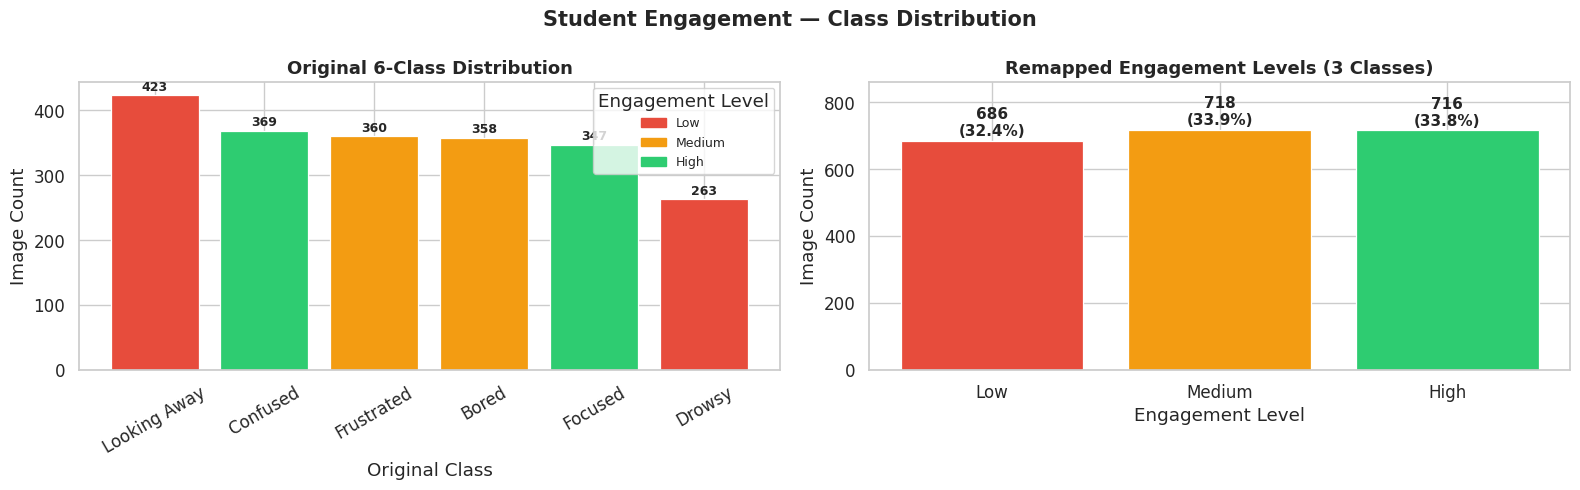


Class imbalance ratio (max/min): 1.05x
→ Moderate imbalance — SMOTE will be applied on training features.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Count images in each original sub-class and colour bars by remapped engagement level
orig_counts = df['original_class'].value_counts()
eng_map     = df.drop_duplicates('original_class').set_index('original_class')['engagement']
bar_colors  = [PALETTE[eng_map[c]] for c in orig_counts.index]

bars = axes[0].bar(orig_counts.index, orig_counts.values,
                   color=bar_colors, edgecolor='white', linewidth=0.9)
axes[0].set_title('Original 6-Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Original Class')
axes[0].set_ylabel('Image Count')
axes[0].tick_params(axis='x', rotation=30)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
patches = [mpatches.Patch(color=PALETTE[l], label=l.capitalize())
           for l in ENGAGEMENT_LABELS]
axes[0].legend(handles=patches, title='Engagement Level', fontsize=9)

# Count images in each of the three remapped engagement levels
eng_counts = df['engagement'].value_counts().reindex(ENGAGEMENT_LABELS)
bars2 = axes[1].bar(
    [e.capitalize() for e in eng_counts.index],
    eng_counts.values,
    color=[PALETTE[e] for e in eng_counts.index],
    edgecolor='white', linewidth=0.9
)
axes[1].set_title('Remapped Engagement Levels (3 Classes)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Engagement Level')
axes[1].set_ylabel('Image Count')
axes[1].set_ylim(0, max(eng_counts.values) * 1.2)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{int(bar.get_height())}\n({int(bar.get_height())/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add a shared title above both subplots and save the figure
plt.suptitle('Student Engagement — Class Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate how many times larger the biggest class is compared to the smallest
imbalance_ratio = eng_counts.max() / eng_counts.min()
print(f'\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}x')
print('→ Moderate imbalance — SMOTE will be applied on training features.')

### 3.2 Image Resolution Analysis

Profile native image dimensions from a random sample of 300 images. The scatter and aspect-ratio histogram confirm whether a uniform resize step is needed.


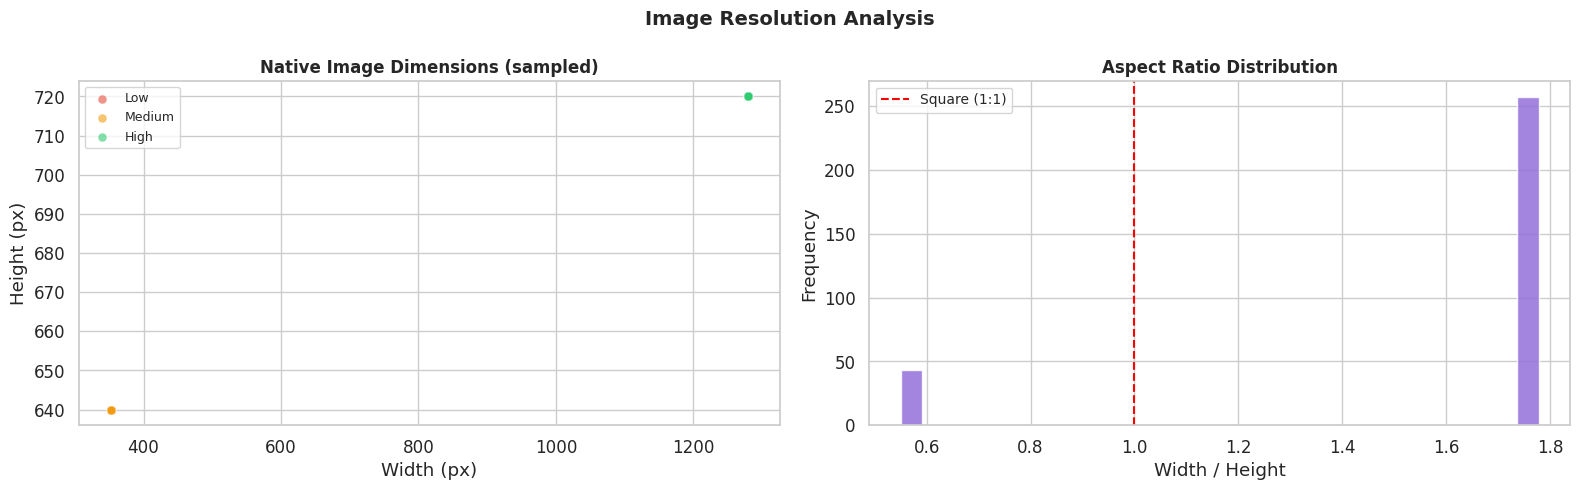

Aspect ratio — mean: 1.60, std: 0.43
→ Images will be resized to 64×64 during preprocessing.


In [ ]:
# Check if images share a native resolution or vary widely
sample_df = df.sample(min(300, len(df)), random_state=RANDOM_STATE).copy()
h_list, w_list, cls_list = [], [], []
# Read each sampled image and record its height and width
for _, row in sample_df.iterrows():
    try:
        img = io.imread(row['path'])
        sh = img.shape
        h_list.append(sh[0])
        w_list.append(sh[1])
        cls_list.append(row['engagement'])
    except Exception:
        pass

# Store the collected dimensions in a dataframe for easy filtering by class
res_df = pd.DataFrame({'height': h_list, 'width': w_list, 'engagement': cls_list})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for eng in ENGAGEMENT_LABELS:
    sub = res_df[res_df['engagement'] == eng]
    axes[0].scatter(sub['width'], sub['height'],
                    c=PALETTE[eng], label=eng.capitalize(),
                    alpha=0.6, edgecolors='white', linewidths=0.3, s=40)
axes[0].set_title('Native Image Dimensions (sampled)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].legend(fontsize=9)

# Aspect-ratio histogram
# Aspect ratio = width / height; values close to 1.0 mean nearly square images
res_df['aspect'] = res_df['width'] / res_df['height']
axes[1].hist(res_df['aspect'], bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
axes[1].set_title('Aspect Ratio Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Width / Height')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=10)

plt.suptitle('Image Resolution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_resolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Aspect ratio — mean: {res_df["aspect"].mean():.2f}, std: {res_df["aspect"].std():.2f}')
print('→ Images will be resized to 64×64 during preprocessing.')

### 3.3 Sample Images per Engagement Level

Display six representative images for each of the three engagement levels to visually confirm that the six-to-three class remapping is semantically sensible.


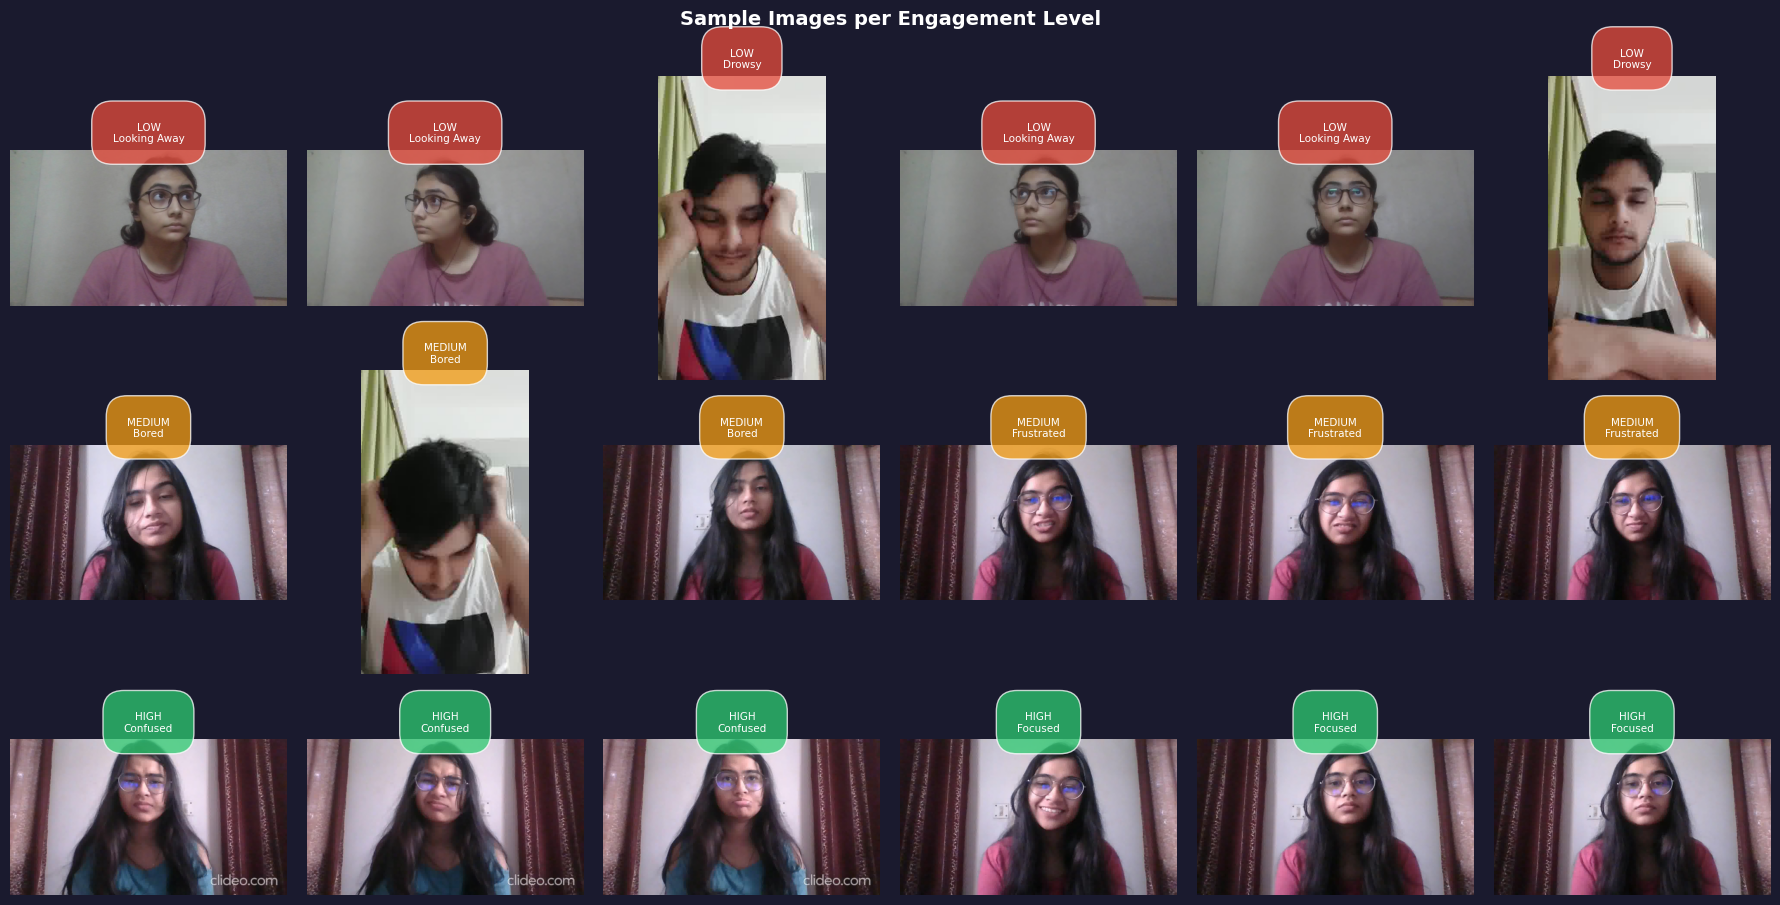

In [ ]:
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.patch.set_facecolor('#1a1a2e')

# Show 6 random images for each engagement level in a 3-row grid
for row_idx, level in enumerate(ENGAGEMENT_LABELS):
    subset = df[df['engagement'] == level].sample(6, random_state=RANDOM_STATE)
    for col_idx, (_, row) in enumerate(subset.iterrows()):
        ax = axes[row_idx, col_idx]
        try:
            img = io.imread(row['path'])
            if img.ndim == 2:
                img = np.stack([img]*3, axis=-1)
            elif img.shape[-1] == 4:
                img = img[..., :3]
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('gray')
# Label each image tile with its engagement level and original sub-class name
        ax.set_title(
            f"{level.upper()}\n{row['original_class']}",
            fontsize=7.5, color='white',
            bbox=dict(facecolor=PALETTE[level], alpha=0.75, pad=2, boxstyle='round')
        )
        ax.axis('off')

# Save the grid of sample images for inclusion in the thesis report
plt.suptitle('Sample Images per Engagement Level', fontsize=14,
             fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_sample_images.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### 3.4 Per-Channel Colour Intensity

Compare the mean R, G, and B channel intensity across engagement levels. Since HOG uses grayscale, this is informational only. it shows whether ambient lighting differs systematically between classes.


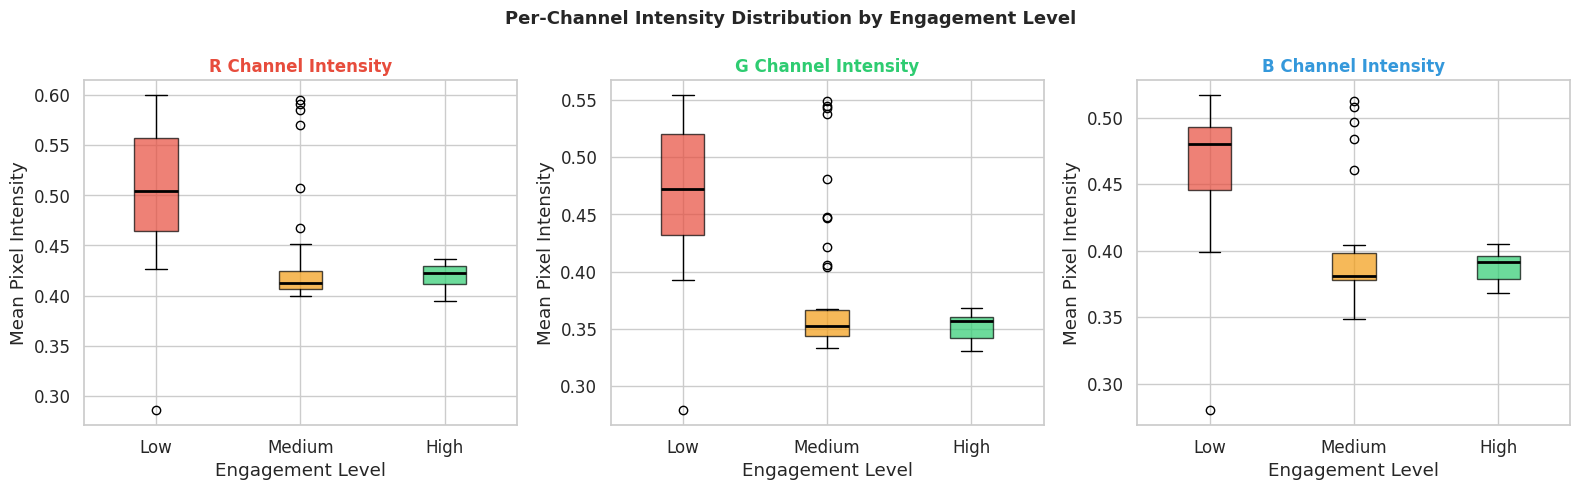

In [ ]:
# Sample a batch to estimate per-class color profiles
N_SAMPLE = 60   # images per class
ch_data  = {eng: {'R': [], 'G': [], 'B': []} for eng in ENGAGEMENT_LABELS}

# For each engagement level, sample 60 images and record their average R, G, B values
for eng in ENGAGEMENT_LABELS:
    subset = df[df['engagement'] == eng].sample(N_SAMPLE, random_state=RANDOM_STATE)
    for _, row in subset.iterrows():
        try:
            img = io.imread(row['path'])
            if img.ndim == 2:
                img = np.stack([img]*3, axis=-1)
            elif img.shape[-1] == 4:
                img = img[..., :3]
            img_f = img_as_float(img)
# img_as_float scales pixel values to [0, 1] before taking the channel mean
            ch_data[eng]['R'].append(img_f[..., 0].mean())
            ch_data[eng]['G'].append(img_f[..., 1].mean())
            ch_data[eng]['B'].append(img_f[..., 2].mean())
        except Exception:
            pass

# One subplot per RGB channel — compare intensity distributions across engagement levels
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
channel_names = ['R', 'G', 'B']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

for ci, (ch, col) in enumerate(zip(channel_names, channel_colors)):
    data_per_class = [ch_data[eng][ch] for eng in ENGAGEMENT_LABELS]
    bp = axes[ci].boxplot(
        data_per_class,
        labels=[e.capitalize() for e in ENGAGEMENT_LABELS],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, eng in zip(bp['boxes'], ENGAGEMENT_LABELS):
        patch.set_facecolor(PALETTE[eng])
        patch.set_alpha(0.7)
    axes[ci].set_title(f'{ch} Channel Intensity', fontsize=12, fontweight='bold', color=col)
    axes[ci].set_xlabel('Engagement Level')
    axes[ci].set_ylabel('Mean Pixel Intensity')

plt.suptitle('Per-Channel Intensity Distribution by Engagement Level',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_channel_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Pixel Intensity Histograms by Original Sub-Class

Plot the grayscale pixel intensity distribution for each of the six original sub-classes. Wider, flatter histograms indicate higher contrast images (e.g. Focused), while narrow peaks indicate uniform low-contrast frames (e.g. Drowsy).


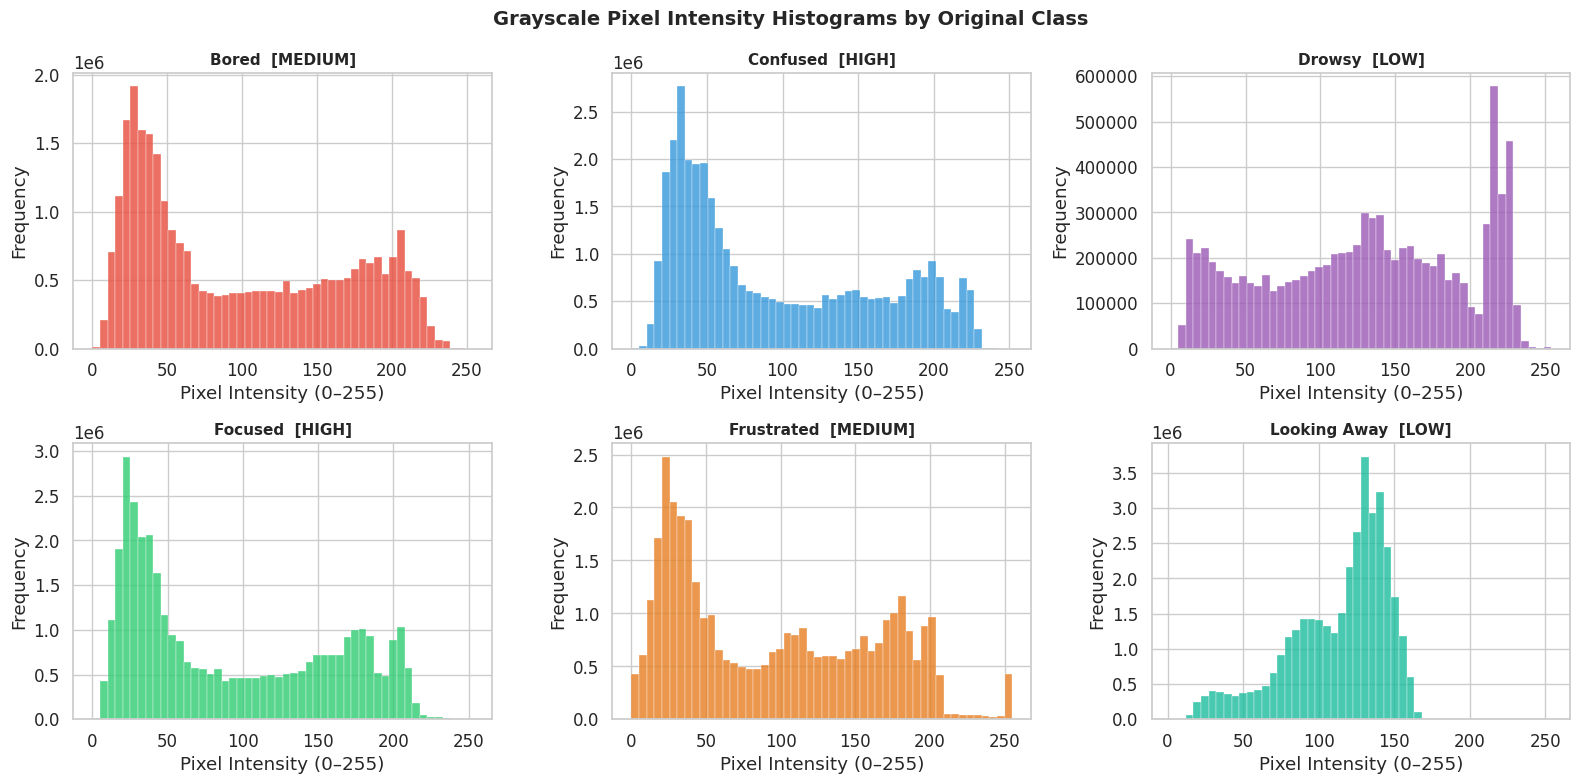

In [ ]:
N_HIST = 40
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

orig_classes = df['original_class'].unique()
# For each original sub-class, flatten all pixel values and plot their histogram
for idx, cls in enumerate(sorted(orig_classes)):
    ax    = axes[idx]
    subset = df[df['original_class'] == cls].sample(N_HIST, random_state=RANDOM_STATE)
    all_pixels = []
    for _, row in subset.iterrows():
        try:
            img = io.imread(row['path'])
            if img.ndim == 2:
                gray = img
            else:
                gray = (color.rgb2gray(img_as_float(img[..., :3])) * 255).astype(np.uint8)
# Convert to grayscale then collect all pixel values into a single list
            all_pixels.extend(gray.flatten().tolist())
        except Exception:
            pass
    ax.hist(all_pixels, bins=50, color=ORIG_PALETTE.get(cls, 'steelblue'),
            alpha=0.8, edgecolor='white', linewidth=0.3)
    eng = df[df['original_class'] == cls]['engagement'].iloc[0]
    ax.set_title(f'{cls}  [{eng.upper()}]', fontsize=11, fontweight='bold')
    ax.set_xlabel('Pixel Intensity (0–255)')
    ax.set_ylabel('Frequency')

# Combined histogram of all pixel values across 40 sampled images per sub-class
plt.suptitle('Grayscale Pixel Intensity Histograms by Original Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_intensity_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Brightness & Contrast Analysis

Compute mean brightness (pixel mean) and contrast (pixel std) for a sample of images per engagement level. Low engagement states are expected to have higher ambient brightness due to reduced attentional narrowing (Qarbal et al., 2025).


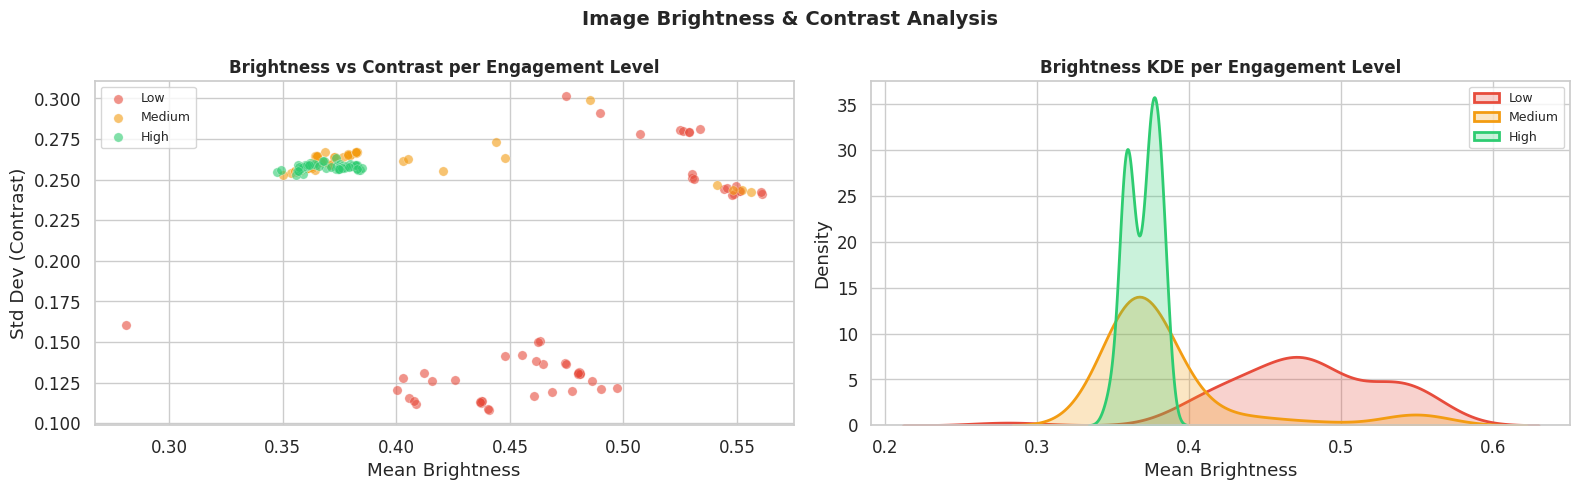


Mean brightness per engagement level:
engagement
high      0.369
low       0.477
medium    0.386


In [ ]:
N_BC = 60
brightness, contrast, labels_bc = [], [], []

for eng in ENGAGEMENT_LABELS:
    subset = df[df['engagement'] == eng].sample(N_BC, random_state=RANDOM_STATE)
    for _, row in subset.iterrows():
        try:
            img = io.imread(row['path'])
            if img.ndim == 3:
                gray = color.rgb2gray(img_as_float(img[..., :3]))
            else:
                gray = img_as_float(img)
# Mean pixel value = brightness; std dev = contrast
            brightness.append(gray.mean())
            contrast.append(gray.std())
            labels_bc.append(eng)
        except Exception:
            pass

# Build a dataframe so we can easily group by engagement level for plotting
bc_df = pd.DataFrame({'brightness': brightness, 'contrast': contrast, 'engagement': labels_bc})

# Two subplots: scatter (brightness vs contrast) and KDE (brightness distribution)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot
for eng in ENGAGEMENT_LABELS:
    sub = bc_df[bc_df['engagement'] == eng]
    axes[0].scatter(sub['brightness'], sub['contrast'],
                    c=PALETTE[eng], label=eng.capitalize(),
                    alpha=0.6, s=45, edgecolors='white', linewidths=0.3)
axes[0].set_title('Brightness vs Contrast per Engagement Level',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Brightness')
axes[0].set_ylabel('Std Dev (Contrast)')
axes[0].legend(fontsize=9)

# KDE for brightness
for eng in ENGAGEMENT_LABELS:
    sub = bc_df[bc_df['engagement'] == eng]
    sns.kdeplot(sub['brightness'], ax=axes[1], label=eng.capitalize(),
                color=PALETTE[eng], linewidth=2, fill=True, alpha=0.25)
axes[1].set_title('Brightness KDE per Engagement Level',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Brightness')
axes[1].set_ylabel('Density')
axes[1].legend(fontsize=9)

plt.suptitle('Image Brightness & Contrast Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_brightness_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMean brightness per engagement level:')
print(bc_df.groupby('engagement')['brightness'].mean().round(3).to_string())

## 4. Image Quality Analysis

Three quality checks are applied before the preprocessing pipeline:

| Check | Method | Action |
|---|---|---|
| Corrupt images | Read attempt + `img.size == 0` guard | Remove unreadable files |
| Exact duplicates | MD5 file hash comparison | Remove duplicate images, keep first occurrence |
| Blur assessment | Laplacian variance (threshold = 100) | **Retain** — screen-recorded faces naturally have soft textures; CLAHE compensates during preprocessing |


### 4.1 Corrupt Image Detection

Attempt to read every image and flag any that cannot be loaded or have zero size. Corrupt images are removed from the dataframe before any further processing.


In [ ]:
# Try to read every image; any that fail or return empty are flagged as corrupt
corrupt_paths = []
for path in df['path']:
    try:
        img = io.imread(path)
        if img is None or img.size == 0:
            corrupt_paths.append(path)
    except Exception:
        corrupt_paths.append(path)

# Report how many images were scanned and how many failed
print(f'Total images    : {len(df):,}')
print(f'Corrupt / unreadable : {len(corrupt_paths)}')

# Remove any corrupt images from the dataframe before further processing
if corrupt_paths:
    print('Corrupt files:')
    for p in corrupt_paths:
        print(f'  {p}')
    # Remove corrupt images from the dataframe
    df = df[~df['path'].isin(corrupt_paths)].reset_index(drop=True)
    print(f'\nDataFrame after dropping corrupt images: {len(df):,} images')
else:
    print('No corrupt images detected.')

Total images    : 2,120
Corrupt / unreadable : 0
No corrupt images detected.


### 4.2 Exact Duplicate Removal

Compute an MD5 hash for every image file. Images with identical hashes are exact duplicates — keeping only the first occurrence prevents the same image appearing in both train and test after the split.


In [ ]:
import hashlib

# Compute an MD5 hash for a file — identical files will produce the same hash
def file_hash(path: str) -> str:
    h = hashlib.md5()
    with open(path, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

# Apply the hash function to every image in the dataframe
df['file_hash'] = df['path'].apply(file_hash)
# Mark duplicate images — keep only the first occurrence of each hash
dupe_mask = df.duplicated(subset='file_hash', keep='first')

# Report the number of duplicates found before removing them
print(f'Duplicate images detected : {dupe_mask.sum()}')
if dupe_mask.sum() > 0:
    df = df[~dupe_mask].reset_index(drop=True)
    print(f'Dataset after de-duplication : {len(df):,} images')
else:
    print('No exact duplicates found.')

Duplicate images detected : 35
Dataset after de-duplication : 2,085 images


### 4.3 Blur (Sharpness) Assessment

Measure sharpness using Laplacian variance — a high value means sharp edges, a low value means blurry. Images below the threshold are **retained** because screen-recorded faces naturally have soft textures; CLAHE applied during preprocessing compensates.


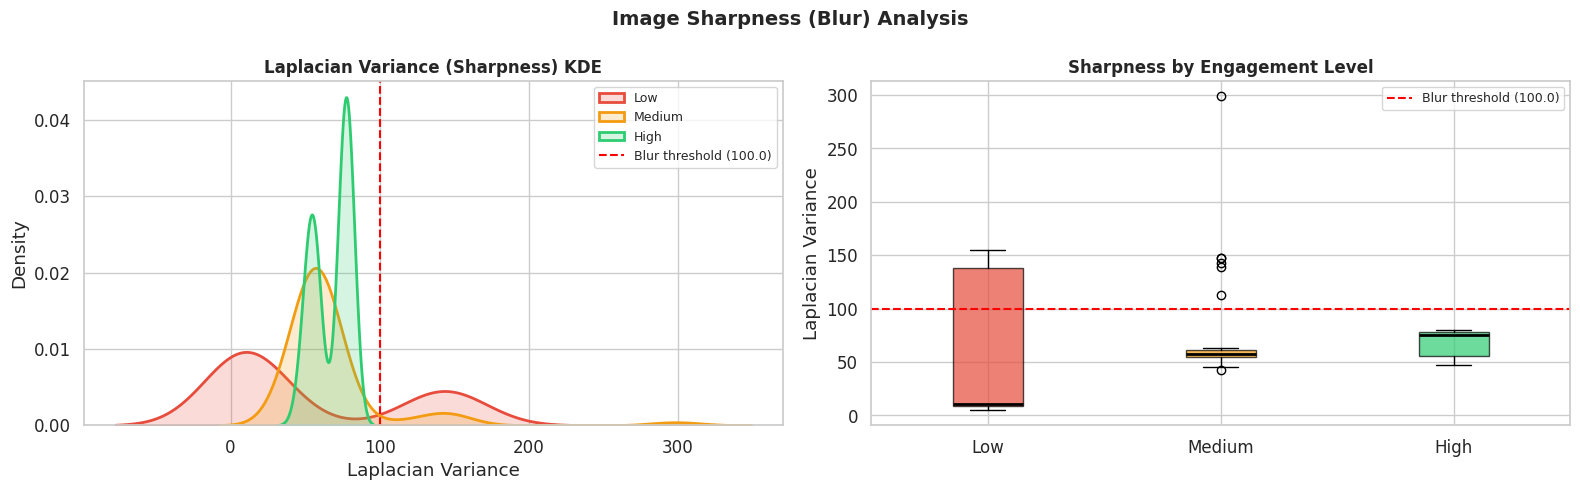


Images below blur threshold (< 100.0): 155 / 180 sampled
→ Blurry images are not removed (face images naturally have soft textures).
  Threshold is informational — CLAHE will enhance local contrast during preprocessing.


In [ ]:
N_BLUR = 60
blur_scores, blur_labels = [], []

for eng in ENGAGEMENT_LABELS:
    subset = df[df['engagement'] == eng].sample(N_BLUR, random_state=RANDOM_STATE)
    for _, row in subset.iterrows():
        try:
            img = io.imread(row['path'])
            if img.ndim == 3:
                gray = cv2.cvtColor(img[..., :3], cv2.COLOR_RGB2GRAY)
            else:
                gray = img
# Laplacian variance measures edge sharpness: high = sharp, low = blurry
            lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
            blur_scores.append(lap_var)
            blur_labels.append(eng)
        except Exception:
            pass

# Collect the sharpness scores and their engagement labels into a dataframe
blur_df = pd.DataFrame({'laplacian_var': blur_scores, 'engagement': blur_labels})
# Images below this threshold are considered blurry (but will still be kept)
BLUR_THRESHOLD = 100.0   # Images below this may be blurry

# Left subplot: KDE of sharpness scores; Right subplot: box plot by engagement level
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for eng in ENGAGEMENT_LABELS:
    sub = blur_df[blur_df['engagement'] == eng]
    sns.kdeplot(sub['laplacian_var'], ax=axes[0], label=eng.capitalize(),
                color=PALETTE[eng], linewidth=2, fill=True, alpha=0.2)
axes[0].axvline(BLUR_THRESHOLD, color='red', linestyle='--',
                label=f'Blur threshold ({BLUR_THRESHOLD})')
axes[0].set_title('Laplacian Variance (Sharpness) KDE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Laplacian Variance')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

data_bp = [blur_df[blur_df['engagement'] == eng]['laplacian_var'].values
           for eng in ENGAGEMENT_LABELS]
bp = axes[1].boxplot(data_bp, labels=[e.capitalize() for e in ENGAGEMENT_LABELS],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, eng in zip(bp['boxes'], ENGAGEMENT_LABELS):
    patch.set_facecolor(PALETTE[eng])
    patch.set_alpha(0.7)
axes[1].axhline(BLUR_THRESHOLD, color='red', linestyle='--',
                label=f'Blur threshold ({BLUR_THRESHOLD})')
axes[1].set_title('Sharpness by Engagement Level', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Laplacian Variance')
axes[1].legend(fontsize=9)

plt.suptitle('Image Sharpness (Blur) Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_sharpness.png', dpi=150, bbox_inches='tight')
plt.show()

n_blurry = (blur_df['laplacian_var'] < BLUR_THRESHOLD).sum()
print(f'\nImages below blur threshold (< {BLUR_THRESHOLD}): {n_blurry} / {len(blur_df)} sampled')
print('→ Blurry images are not removed (face images naturally have soft textures).')
print('  Threshold is informational — CLAHE will enhance local contrast during preprocessing.')

## 5. Preprocessing Pipeline

### Strategy
| Step | Technique | Rationale |
|---|---|---|
| Resize | 64×64 (HOG input) | Uniform spatial resolution for feature extraction |
| Grayscale | `skimage.color.rgb2gray` | HOG is texture-based; colour adds noise |
| CLAHE | Contrast-limited adaptive histogram equalisation | Corrects uneven lighting across face images |
| Normalise | Scale pixel values to [0, 1] float32 | Stable gradient computation for HOG |
| HOG | 9 orientations, 8×8 cells, 2×2 blocks, L2-Hys | Captures face/body posture shape features |
| StandardScaler | Zero mean, unit variance on HOG features | Required for SVM; also helps XGBoost |
| SMOTE | On training HOG features **only** | Balances minority class without test leakage |

### 5.1 Preprocessing & HOG Functions

Define three reusable functions:
- `preprocess_image` — resize → grayscale → CLAHE → normalise
- `extract_hog_features` — compute a 1,764-dimensional HOG descriptor from a 64×64 image
- `batch_preprocess_and_hog` — apply both functions to an entire split


In [ ]:
def preprocess_image(path: str,
                     target_size: tuple = IMG_SIZE,
                     apply_clahe: bool  = True) -> np.ndarray:
    """
    Full single-image preprocessing pipeline.
    Returns a grayscale float32 array of shape (H, W) in [0, 1].

    Steps
    -----
    1. Read & handle alpha channel / grayscale images.
    2. Resize to target_size with anti-aliasing.
    3. Convert to grayscale.
    4. CLAHE (optional) — adaptive contrast enhancement.
    5. Normalise to [0, 1] float32.
    """
    img = io.imread(path)

    # Handle alpha or grayscale inputs
# Make sure every image is 3-channel before resizing, even if it was grayscale
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 4:
        img = img[..., :3]

    # Resize (anti_aliasing avoids aliasing artefacts)
    img_resized = transform.resize(img, target_size,
                                   anti_aliasing=True,
                                   preserve_range=True).astype(np.uint8)

    # Convert to grayscale
# Convert resized colour image to grayscale — HOG needs a single-channel input
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

    # CLAHE — handles variable lighting in classroom images
    if apply_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        gray  = clahe.apply(gray)

    # Normalise to [0, 1]
    return (gray / 255.0).astype(np.float32)

def extract_hog_features(img_gray: np.ndarray) -> np.ndarray:
    """
    Extract HOG feature vector from a single preprocessed grayscale image.

    Parameters chosen for 64×64 face images:
      - 9 orientations   : captures fine gradient directions
      - 8×8 pixels/cell  : 8×8 grid gives 64 cells per image
      - 2×2 cells/block  : 4-cell normalisation window
      - L2-Hys norm      : robust to contrast changes
    """
    fd = hog(
        img_gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return fd.astype(np.float32)

def batch_preprocess_and_hog(dataframe: pd.DataFrame,
                              target_size: tuple = IMG_SIZE,
                              apply_clahe: bool  = True,
                              desc: str = '') -> tuple:
    """
    Process an entire split and return (X_hog, y) arrays.
    Skips corrupted images silently.
    """
    X, y, valid_idx = [], [], []
    n = len(dataframe)
    print(f'Processing {desc} — {n} images …')

    for i, (_, row) in enumerate(dataframe.iterrows()):
        if i % 200 == 0:
            print(f'  {i:>4d}/{n}', end='\r')
        try:
            gray = preprocess_image(row['path'], target_size, apply_clahe)
            hog_feat = extract_hog_features(gray)
            X.append(hog_feat)
            y.append(row['label'])
            valid_idx.append(i)
        except Exception:
            pass

    print(f'  Done. Valid: {len(X)}/{n}')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Preprocessing functions defined.')
print(f'   HOG feature length (estimated): ~{len(extract_hog_features(np.zeros(IMG_SIZE, dtype=np.float32)))} dims')

Preprocessing functions defined.
   HOG feature length (estimated): ~1764 dims


### 5.2 Step-by-Step Pipeline Visualisation

Show each preprocessing step side-by-side for three images per engagement level: Original → Resized → Grayscale → CLAHE → HOG overlay. This confirms each transformation is working correctly before features are extracted at scale.


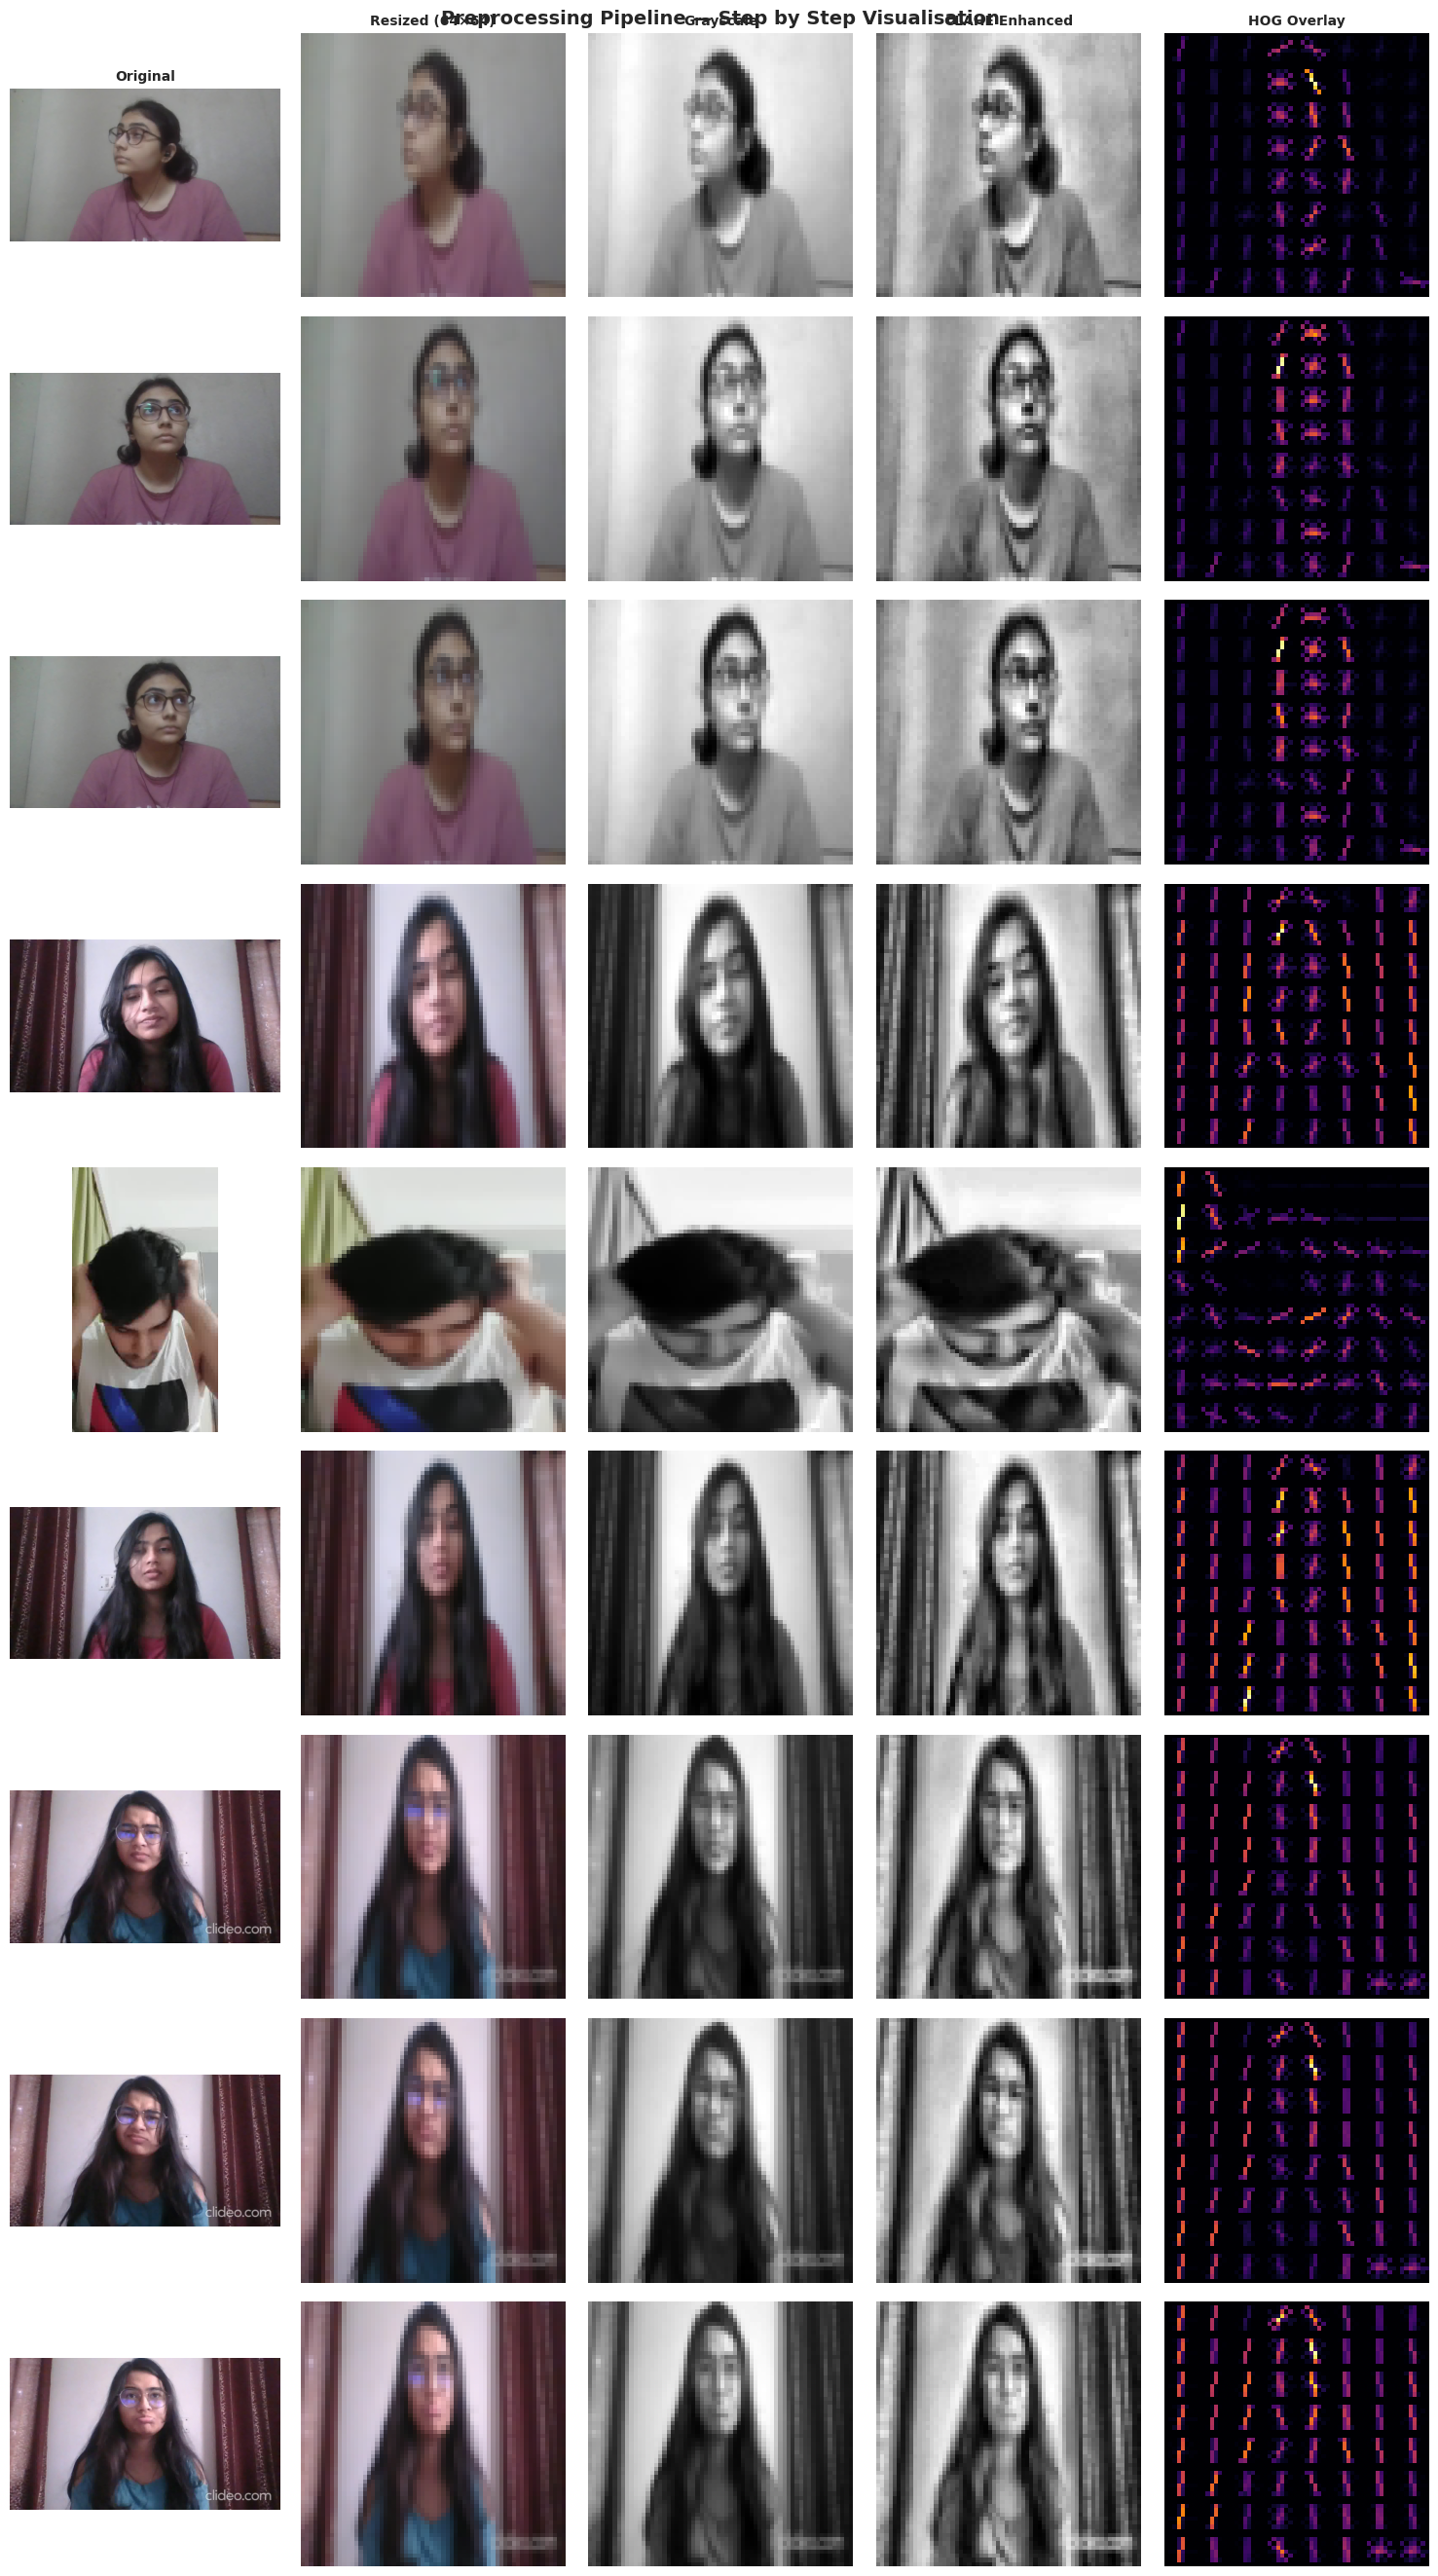

In [ ]:
SHOW_N  = 3   # images per engagement level
n_rows  = len(ENGAGEMENT_LABELS) * SHOW_N
n_cols  = 5   # original | resized | grayscale | CLAHE | HOG overlay

# Each row = one image; each column = one processing stage
col_titles = ['Original', 'Resized (64×64)', 'Grayscale', 'CLAHE Enhanced', 'HOG Overlay']
fig, axes  = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))

row = 0
for eng in ENGAGEMENT_LABELS:
    subset = df[df['engagement'] == eng].sample(SHOW_N, random_state=RANDOM_STATE)
    for _, rec in subset.iterrows():
        try:
            img = io.imread(rec['path'])
            if img.ndim == 2:
                img = np.stack([img]*3, axis=-1)
            elif img.shape[-1] == 4:
                img = img[..., :3]

            img_r = transform.resize(img, IMG_SIZE,
                                     anti_aliasing=True,
                                     preserve_range=True).astype(np.uint8)
            gray   = cv2.cvtColor(img_r, cv2.COLOR_RGB2GRAY)
            clahe  = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            clahe_img = clahe.apply(gray)
            clahe_f = (clahe_img / 255.0).astype(np.float32)

            # HOG visualisation
# Generate HOG image for the last column — shows gradient orientations visually
            _, hog_vis = hog(clahe_f, orientations=9,
                             pixels_per_cell=(8,8), cells_per_block=(2,2),
                             block_norm='L2-Hys', visualize=True)
            hog_vis = exposure.rescale_intensity(hog_vis, in_range=(0, 0.4))

            steps = [img, img_r, gray, clahe_img, hog_vis]
            cmaps = [None, None, 'gray', 'gray', 'inferno']

            for col_idx, (step, cmap) in enumerate(zip(steps, cmaps)):
                ax = axes[row, col_idx]
                ax.imshow(step, cmap=cmap)
                if row == 0:
                    ax.set_title(col_titles[col_idx], fontsize=10, fontweight='bold')
                if col_idx == 0:
                    ax.set_ylabel(
                        f"{eng.upper()}\n{rec['original_class']}",
                        fontsize=8, rotation=90,
                        color='white',
                        bbox=dict(facecolor=PALETTE[eng], alpha=0.7, pad=2, boxstyle='round')
                    )
                ax.axis('off')
        except Exception as e:
            for col_idx in range(n_cols):
                axes[row, col_idx].axis('off')
        row += 1

# Save the step-by-step visualisation grid to the output directory
plt.suptitle('Preprocessing Pipeline — Step by Step Visualisation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_steps.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 CLAHE Effect on a Single Image

Zoom in on one image to show how CLAHE redistributes pixel intensities. The before/after pixel histograms show that CLAHE spreads the intensity range, making facial gradients more visible for HOG extraction.


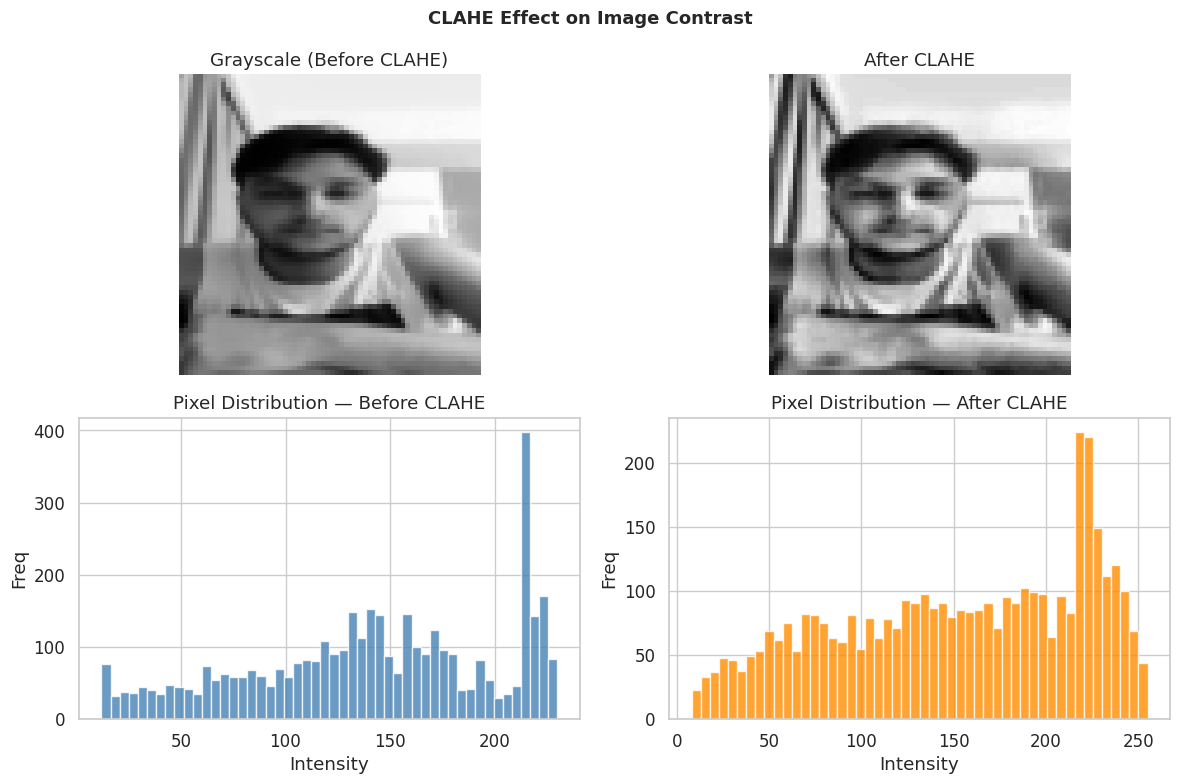

In [ ]:
sample_path = df[df['engagement'] == 'low'].iloc[0]['path']
img_raw  = io.imread(sample_path)
if img_raw.ndim == 3:
    img_raw = img_raw[..., :3]
img_r    = transform.resize(img_raw, IMG_SIZE, anti_aliasing=True, preserve_range=True).astype(np.uint8)
# Convert the resized image to grayscale first, then apply CLAHE
gray_raw = cv2.cvtColor(img_r, cv2.COLOR_RGB2GRAY)
clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
# CLAHE enhances local contrast in dark/bright regions independently
gray_cl  = clahe.apply(gray_raw)

# Top row: image before and after CLAHE; Bottom row: pixel intensity histogram
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(gray_raw, cmap='gray'); axes[0, 0].set_title('Grayscale (Before CLAHE)')
axes[0, 1].imshow(gray_cl,  cmap='gray'); axes[0, 1].set_title('After CLAHE')

axes[1, 0].hist(gray_raw.flatten(), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Pixel Distribution — Before CLAHE')
axes[1, 0].set_xlabel('Intensity'); axes[1, 0].set_ylabel('Freq')

axes[1, 1].hist(gray_cl.flatten(),  bins=50, color='darkorange', alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Pixel Distribution — After CLAHE')
axes[1, 1].set_xlabel('Intensity'); axes[1, 1].set_ylabel('Freq')

for ax in axes.flatten():
    ax.axis('off') if ax in axes[:, :2].flatten()[:2] else None

plt.suptitle('CLAHE Effect on Image Contrast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'preprocessing_clahe_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Block-Based Train/Test Split & HOG Feature Extraction

This dataset is **video-derived**: consecutive images are sequential frames from the same recording session. A naive random 80/20 split would scatter temporally correlated frames across train and test, allowing the model to memorise recordings rather than generalise — inflating test accuracy by up to 10 percentage points (Qarbal, Sael and Ouahabi, 2025).

`GroupShuffleSplit` is used with block IDs as the grouping key, ensuring every frame from a given recording block lands exclusively in either the training set or the test set.



### 6.1 Assign Block IDs

Sort images by class and filename, then label every 30 consecutive frames with the same `block_id`. The block ID is used as the grouping key in `GroupShuffleSplit` to ensure no recording session straddles the train/test boundary.


In [ ]:
BLOCK_SIZE = 30  # Frames per block; all frames in a block stay in the same split

# Sorting ensures that consecutive frames from the same video end up adjacent in the dataframe
df = df.sort_values(['original_class', 'filename']).reset_index(drop=True)
# Number each image within its class (0, 1, 2, …) to identify frame order
df['seq_within_class'] = df.groupby('original_class').cumcount()
# Integer-divide the sequence number by BLOCK_SIZE to get the block index
# e.g. frames 0-29 → block_0, frames 30-59 → block_1, etc.
df['block_id'] = (df['original_class'] + '_block_'
                  + (df['seq_within_class'] // BLOCK_SIZE).astype(str))

# Count how many unique blocks were created across all classes
n_blocks = df['block_id'].nunique()
print(f'Block IDs assigned  : {n_blocks} blocks ({BLOCK_SIZE} frames each)')
print(f'Total images        : {len(df):,}')
print()
print(df.groupby('original_class')['block_id'].nunique()
        .rename('num_blocks').to_string())

print('\nAvg frames per block per class:')
print(df.groupby(['original_class', 'block_id']).size()
        .groupby('original_class').mean().round(1)
        .rename('avg_frames').to_string())

Block IDs assigned  : 72 blocks (30 frames each)
Total images        : 2,085

original_class
Bored           12
Confused        13
Drowsy           8
Focused         12
Frustrated      12
Looking Away    15

Avg frames per block per class:
original_class
Bored           29.8
Confused        28.4
Drowsy          28.5
Focused         28.9
Frustrated      30.0
Looking Away    28.2


### 6.2 GroupShuffleSplit - Leakage-Free Partition

Perform the 80/20 split at the block level. An `assert` statement explicitly verifies that zero blocks appear in both splits. The class distribution chart confirms that both splits contain all three engagement levels.


Train : 1,635 images  |  57 blocks
Test  : 450 images   |  15 blocks

Block overlap between train and test : 0 (must be 0)
No block overlap — split is leakage-free.


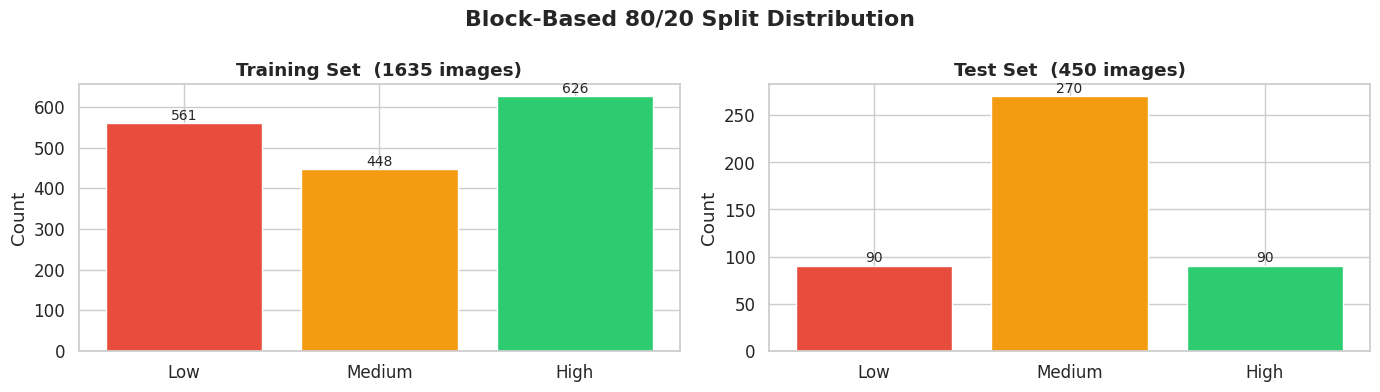

In [ ]:
# GroupShuffleSplit: each block_id goes entirely to train or test — zero frame overlap

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SPLIT, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df['block_id']))

# Use the block indices to slice the dataframe into two non-overlapping splits
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

print(f'Train : {len(train_df):,} images  |  {train_df["block_id"].nunique()} blocks')
print(f'Test  : {len(test_df):,} images   |  {test_df["block_id"].nunique()} blocks')

# Verify NO block appears in both splits (the whole point of this fix)
train_blocks = set(train_df['block_id'])
test_blocks  = set(test_df['block_id'])
# Double-check that no block ID appears in both splits — this must always be zero
overlap = train_blocks & test_blocks
print(f'\nBlock overlap between train and test : {len(overlap)} (must be 0)')
# Hard assertion: if any block leaked, raise an error immediately
assert len(overlap) == 0, 'Block overlap detected — check BLOCK_SIZE!'
print('No block overlap — split is leakage-free.')

# Class distribution chart
# Visualise the class distribution in each split to check for balance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (split_df, title) in zip(axes, [(train_df, 'Training Set'), (test_df, 'Test Set')]):
    counts = split_df['engagement'].value_counts().reindex(ENGAGEMENT_LABELS)
    bars   = ax.bar([e.capitalize() for e in counts.index], counts.values,
                    color=[PALETTE[e] for e in counts.index], edgecolor='white')
    ax.set_title(f'{title}  ({len(split_df)} images)', fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Block-Based 80/20 Split Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'split_distribution.png', dpi=150)
plt.show()


### 6.3 Extract HOG Features for Both Splits

Run `batch_preprocess_and_hog` on the training and test subsets. The resulting arrays `X_train_raw` and `X_test` are 2-D: rows = images, columns = HOG dimensions.


In [ ]:
# Apply the full preprocessing + HOG pipeline to every image in each split
# X = matrix of HOG feature vectors, y = integer engagement labels
X_train_raw, y_train_raw = batch_preprocess_and_hog(train_df, desc='training set')
X_test,      y_test      = batch_preprocess_and_hog(test_df,  desc='test set')

# Confirm the shape of the HOG arrays before proceeding to training
print(f'\nHOG feature vector length : {X_train_raw.shape[1]}')
print(f'Train HOG shape : {X_train_raw.shape}')
print(f'Test  HOG shape : {X_test.shape}')

Processing training set — 1635 images …
  Done. Valid: 1635/1635
Processing test set — 450 images …
  Done. Valid: 450/450

HOG feature vector length : 1764
Train HOG shape : (1635, 1764)
Test  HOG shape : (450, 1764)


## 7. HOG Feature Visualisation

Two visualisations confirm that the HOG descriptor encodes engagement-discriminative information (Figures 3.10–3.11):

- **HOG overlay grid** — gradient orientation patterns per class. High engagement images show stronger periocular gradient activity consistent with increased alertness; Low engagement images show diffuse, low-magnitude gradients associated with drooping eyelids
- **Mean HOG feature vectors** — per-class mean across the first 200 dimensions. Visible separation between class profiles confirms that the feature space is learnable


### 7.1 HOG Overlay Grid by Engagement Class

Render the HOG gradient field as a heatmap for four sample images per class. High engagement images show denser, more structured gradient patterns around the eye region; low engagement images show sparse, diffuse gradients.


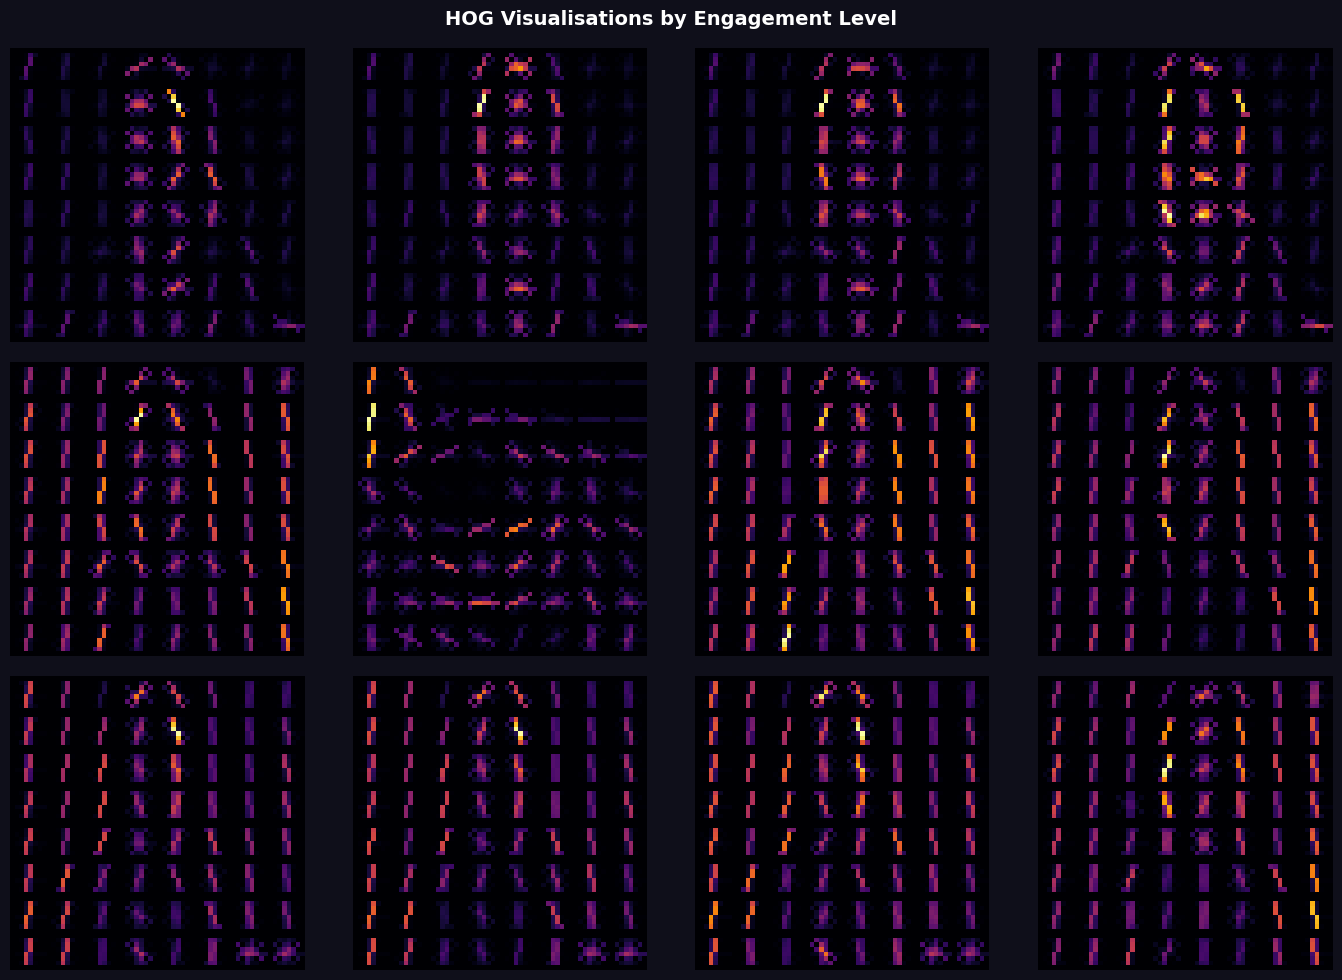

In [ ]:
fig, axes = plt.subplots(len(ENGAGEMENT_LABELS), 4, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')

for r, eng in enumerate(ENGAGEMENT_LABELS):
    subset = df[df['engagement'] == eng].sample(4, random_state=RANDOM_STATE)
    for c, (_, rec) in enumerate(subset.iterrows()):
        ax = axes[r, c]
        try:
# Preprocess the image then compute HOG with visualize=True to get the overlay
            gray_pp = preprocess_image(rec['path'])
            _, hog_vis = hog(gray_pp, orientations=9,
                             pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                             block_norm='L2-Hys', visualize=True)
# Rescale HOG values for display — makes the gradient orientations easier to see
            hog_vis = exposure.rescale_intensity(hog_vis, in_range=(0, 0.4))
            ax.imshow(hog_vis, cmap='inferno')
        except Exception:
            ax.set_facecolor('black')
        if c == 0:
            ax.set_ylabel(eng.upper(), fontsize=10, color='white', fontweight='bold')
        ax.axis('off')

# Save the HOG overlay grid — used as Figure 3.10 in the thesis
plt.suptitle('HOG Visualisations by Engagement Level',
             fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hog_visualisations.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

### 7.2 Mean HOG Feature Vector per Engagement Level

Average the HOG feature vectors across all training images in each class and plot the first 200 dimensions. Visible separation between the three class-mean lines confirms that the HOG descriptor encodes engagement-relevant information.


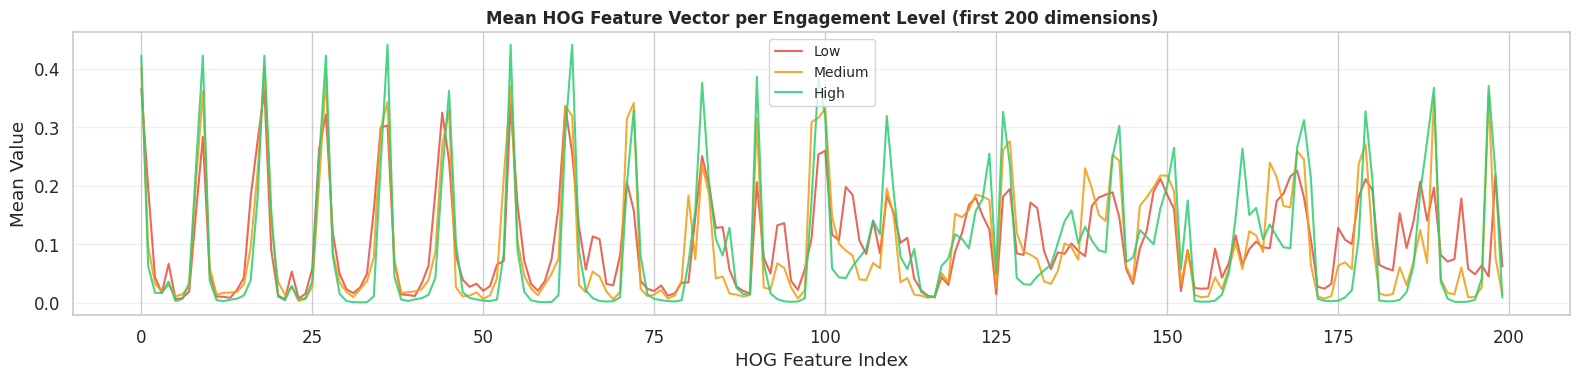

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

N_PLOT = 200   # plot first 200 HOG dims for readability

for eng_idx, eng in enumerate(ENGAGEMENT_LABELS):
# Select training samples belonging to this engagement level and average their HOG vectors
    mask    = y_train_raw == LABEL_ENC[eng]
    mean_hog = X_train_raw[mask, :N_PLOT].mean(axis=0)
    ax.plot(mean_hog, label=eng.capitalize(), color=PALETTE[eng], linewidth=1.5, alpha=0.85)

# If the three curves are visually separated, HOG is encoding class differences
ax.set_title(f'Mean HOG Feature Vector per Engagement Level (first {N_PLOT} dimensions)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('HOG Feature Index')
ax.set_ylabel('Mean Value')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hog_mean_vectors.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Class Imbalance: SMOTE

The block-based training split produces an imbalanced class distribution (Low: ~769, Medium: ~549, High: ~317 — ratio ≈ 2.4:1). SMOTE is applied exclusively to the training HOG feature vectors to generate synthetic minority-class samples by interpolating between existing instances in feature space (Chawla et al., 2002).

> **Critical constraint:** SMOTE is applied *after* the train/test split. The test set is never resampled — synthetic samples are confined to the training partition to prevent any form of data leakage.


### 8.1 Apply SMOTE to Training Features

SMOTE generates new synthetic minority-class samples by interpolating between existing training examples in HOG feature space. `k_neighbors=5` means each new sample is placed between a real example and one of its five nearest real neighbours.


In [ ]:
# Test set is NEVER touched — no leakage.
print('Class counts BEFORE SMOTE (train):')
before = Counter(y_train_raw)
for lbl in sorted(before):
    print(f'  {LABEL_DEC[lbl]:8s} : {before[lbl]}')

# k_neighbors=5: each synthetic sample is interpolated between a real sample
# and one of its five nearest real neighbours in HOG feature space
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
# fit_resample generates synthetic samples for minority classes only
# and returns a balanced training set (test set is never touched)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

# Print the new balanced counts — all three classes should now be equal
print('\nClass counts AFTER SMOTE (train):')
after = Counter(y_train)
for lbl in sorted(after):
    print(f'  {LABEL_DEC[lbl]:8s} : {after[lbl]}')

print(f'\nTraining set size after SMOTE : {len(y_train):,}')

Class counts BEFORE SMOTE (train):
  low      : 561
  medium   : 448
  high     : 626

Class counts AFTER SMOTE (train):
  low      : 626
  medium   : 626
  high     : 626

Training set size after SMOTE : 1,878


### 8.2 Before vs After SMOTE — Class Distribution Chart

Side-by-side bars show class counts in the training set before (faded) and after (solid) SMOTE. All three classes should reach the same count after balancing.


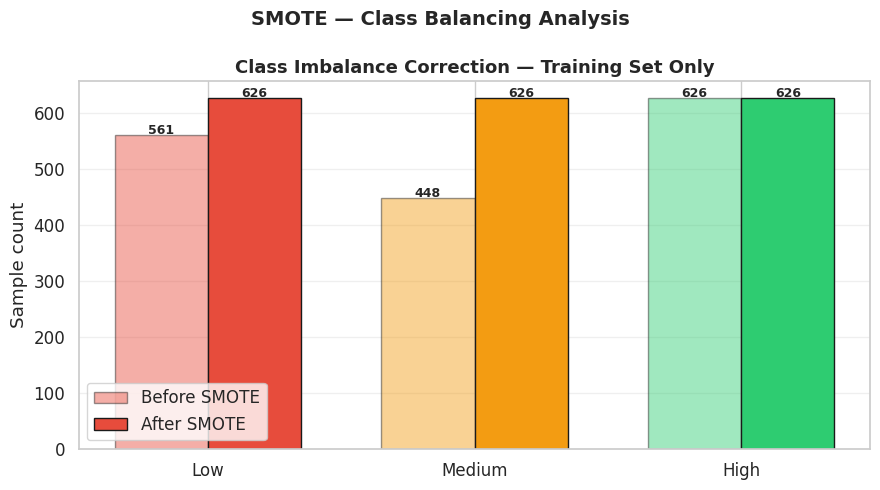

In [ ]:
labels_sorted = [LABEL_DEC[i] for i in sorted(before.keys())]
x = np.arange(len(labels_sorted))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

# Faded bars = original counts, solid bars = counts after SMOTE balancing
b1 = ax.bar(x - w/2, [before[i] for i in sorted(before)], w,
             label='Before SMOTE',
             color=[PALETTE[l] for l in labels_sorted], alpha=0.45, edgecolor='k')
b2 = ax.bar(x + w/2, [after[i]  for i in sorted(after)],  w,
             label='After SMOTE',
             color=[PALETTE[l] for l in labels_sorted], alpha=1.00, edgecolor='k')
ax.set_xticks(x)
ax.set_xticklabels([l.capitalize() for l in labels_sorted], fontsize=12)
ax.set_ylabel('Sample count')
ax.set_title('Class Imbalance Correction — Training Set Only',
             fontweight='bold', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

# Save the SMOTE chart — used as Figure 3.9 in the thesis
plt.suptitle('SMOTE — Class Balancing Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'smote_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Feature Scaling & Export

`StandardScaler` is fitted exclusively on the SMOTE-balanced training set, then applied as a transform to both training and test arrays. This strict **fit-on-train-only** protocol ensures that no information about the test set's distribution influences the scaling parameters.


### 9.1 Fit StandardScaler & Transform Both Splits

The scaler is fitted only on the training data. The same mean and standard deviation values are then applied to the test set — this is critical to avoid leaking test distribution information into the model.


In [ ]:
# Fit on SMOTE-balanced training set; apply same parameters to test (no leakage)
scaler     = StandardScaler()
# fit_transform: learn the mean & std from training data, then scale it
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
# transform only: apply the same mean & std learned from training — no re-fitting
X_test_sc  = scaler.transform(X_test)        # apply same parameters to test

# Confirm the scaled arrays have the same shape as the originals
print(f'Scaled train shape : {X_train_sc.shape}')
print(f'Scaled test  shape : {X_test_sc.shape}')
print(f'\nScaler mean  — min: {scaler.mean_.min():.4f}, max: {scaler.mean_.max():.4f}')
print(f'Scaler scale — min: {scaler.scale_.min():.4f}, max: {scaler.scale_.max():.4f}')

Scaled train shape : (1878, 1764)
Scaled test  shape : (450, 1764)

Scaler mean  — min: 0.0049, max: 0.4022
Scaler scale — min: 0.0090, max: 0.1821


### 9.2 Feature Distribution Before vs After Scaling

Plot the raw and scaled values for three randomly selected HOG dimensions. After scaling, each dimension should have approximately zero mean and unit variance.


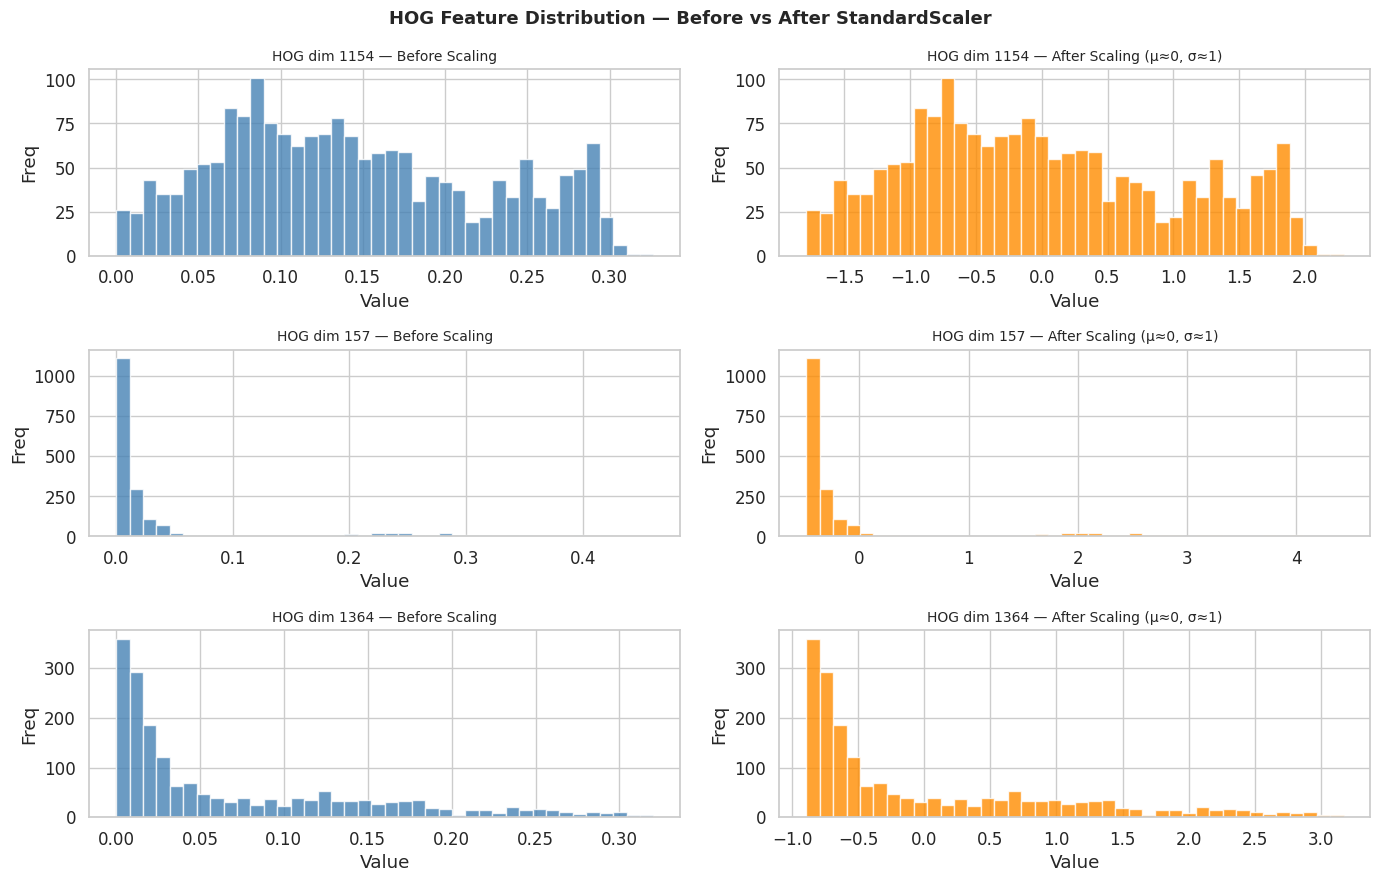

In [ ]:
DIM_SHOW = 3   # show distributions for 3 random HOG features
rng      = np.random.default_rng(42)
# Pick 3 random HOG dimensions to check that scaling worked correctly
feat_idx = rng.choice(X_train.shape[1], size=DIM_SHOW, replace=False)

fig, axes = plt.subplots(DIM_SHOW, 2, figsize=(14, DIM_SHOW * 3))

for r, fi in enumerate(feat_idx):
# Before scaling: raw HOG values (range and scale vary per dimension)
    axes[r, 0].hist(X_train[:, fi], bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    axes[r, 0].set_title(f'HOG dim {fi} — Before Scaling', fontsize=10)
    axes[r, 0].set_xlabel('Value'); axes[r, 0].set_ylabel('Freq')

# After scaling: values re-centred to mean≈0 and std≈1
    axes[r, 1].hist(X_train_sc[:, fi], bins=40, color='darkorange', alpha=0.8, edgecolor='white')
    axes[r, 1].set_title(f'HOG dim {fi} — After Scaling (μ≈0, σ≈1)', fontsize=10)
    axes[r, 1].set_xlabel('Value'); axes[r, 1].set_ylabel('Freq')

# A successful scaling should centre the orange histogram at 0 with unit spread
plt.suptitle('HOG Feature Distribution — Before vs After StandardScaler',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.3 Save All Files

In [ ]:
import joblib

np.save(OUTPUT_DIR / 'X_train_hog.npy',  X_train)
np.save(OUTPUT_DIR / 'y_train.npy',      y_train)
np.save(OUTPUT_DIR / 'X_test_hog.npy',   X_test)
np.save(OUTPUT_DIR / 'y_test.npy',       y_test)

np.save(OUTPUT_DIR / 'X_train_hog_scaled.npy', X_train_sc)
np.save(OUTPUT_DIR / 'X_test_hog_scaled.npy',  X_test_sc)

joblib.dump(scaler, OUTPUT_DIR / 'hog_scaler.pkl')

df.to_csv(OUTPUT_DIR / 'dataset_metadata.csv', index=False)

print('All preprocessed files saved')

All preprocessed files saved
